In [48]:
import numpy as np 
import scipy.signal as sig
from matplotlib.animation import FuncAnimation
import matplotlib.pyplot as plt
from IPython.display import HTML

t0 = 0
tmax = 250
h = 0.125e-3
N = int((tmax - t0) / h)

def rk4(**params):

    R  = params.get("R", 47.0)
    Rv = params.get("Rv", 70.0)
    R0 = params.get("R0", 157.0)
    Vc = params.get("Vc", 0.25)
    k = params.get("k", 6)
    C  = params.get("C", 1e-3)
    x0  = params.get("x0", np.array([0,0,R/R0 * Vc]))

    def f(t,V):
        ftV = np.array([V[1],
                        V[2],
                -R/Rv * V[2]-V[1] - R/R0*Vc
        ])
        if V[0] < 0:
            ftV[2] -= k *V[0]        
        return ftV
    
    m = np.size(x0)                             
    t = np.linspace(t0, tmax, N+1)  
    x = np.zeros((N+1, m))            

    x[0,:] = x0                    
    for n in range(N):             
        k1 = f(t[n],       x[n,:]             )
        k2 = f(t[n] + h/2, x[n,:] + (h/2) * k1)
        k3 = f(t[n] + h/2, x[n,:] + (h/2) * k2)
        k4 = f(t[n] + h,   x[n,:] +     h * k3)
        x[n+1,:] = x[n,:] + (h/6) * ( k1 + 2*k2 + 2*k3 + k4 )  
    t_real = t * R * C
    return t_real, x, Rv

    """
    A 4-stage Runge-Kutta method for a system of first order ODEs 
      y' = f(t,y) for t in [t0, tmax] using N steps

    Parameters
    ----------
    f    : function f(t,y) returns an array of size m
    t0   : initial time
    tmax : final time
    N    : number of time steps
    y0   : initial value as an array of size m

    Returns
    -------
    t    : an array of size N+1
    y    : a matrix of size N+1 by m
    
    (Frances Kuo 25 March 2023)
    """


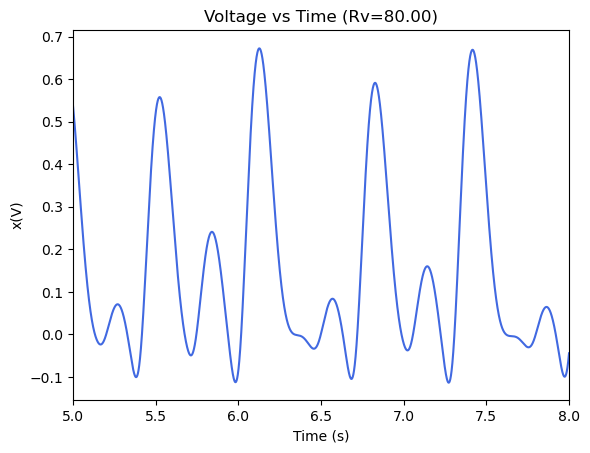

In [34]:
time,x, Rv = rk4(Rv=80)

voltage = x[:,0]

plt.plot(time,voltage,c='royalblue')
plt.xlim(5,8)
plt.xlabel('Time (s)')
plt.ylabel("x(V)")
plt.title(f"Voltage vs Time (Rv={Rv:.2f})")
plt.show()

11.75


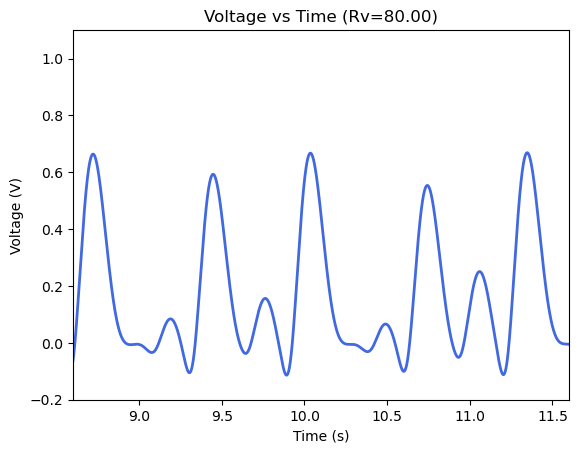

In [ ]:
t, x, Rv = rk4(Rv=80)
voltages = x[:,0]
print(t[-1])
fig, ax = plt.subplots()

ax.set_ylim(-0.2, 1.1)

ln, = plt.plot(t,voltages,lw=2,color='royalblue')
ax.set_title(f"Voltage vs Time (Rv={Rv:.2f})")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Voltage (V)")

window_width = 3
step = 0.1

def update(frame):
    start = t[0] + frame * step
    end = start + window_width
    ax.set_xlim(start,end)
    return ln,

ani = FuncAnimation(fig, update, frames=range(0,int((t[-1]-t[0]-window_width)/step)),blit=True,interval=200)
HTML(ani.to_jshtml())
ani.save("../Model_Figures/voltage_scan.gif", writer="pillow", fps=10)

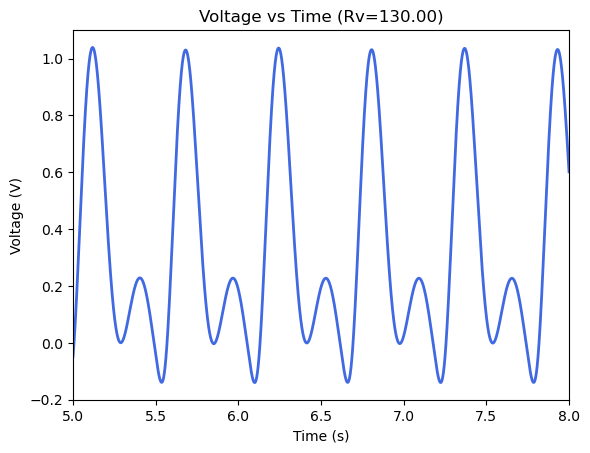

In [35]:
fig, ax = plt.subplots()

ax.set_xlim(5, 8)
ax.set_ylim(-0.2, 1.1)

ln, = ax.plot([],[],lw=2,color='royalblue')

ax.set_xlabel("Time (s)")
ax.set_ylabel("Voltage (V)")

def init():
    ln.set_data([],[])
    return ln,

def update(frame):
    Rv = Rv_values[frame]

    t,x,_ = rk4(Rv=Rv)
    voltages = x[:,0]
    ln.set_data(t, voltages)
    ax.set_title(f"Voltage vs Time (Rv={Rv:.2f})")
    return ln,

Rv_values = np.linspace(50, 130, 100)

ani = FuncAnimation(fig, update, frames=len(Rv_values),init_func=init,blit=True,interval=200)
HTML(ani.to_jshtml())
ani.save("../Model_Figures/voltage_animation.gif", writer="pillow", fps=5)

In [ ]:
Rv_range = np.linspace(50,130,500)

Rv_values = []
peaks_voltages = []

for i in Rv_range:
    time,x,_ = rk4(Rv=i)
    voltages = x[:,0]
    peaks, _ = sig.find_peaks(voltages)
    peak_values = voltage[peaks]

    Rv_values.extend([i]*len(peak_values))
    peaks_voltages.extend(peak_values)

plt.scatter(Rv_values,peaks_voltages,s=3,color='lightgrey',alpha=0.5)
plt.xlabel(r'$R_v(k\Omega)$')
plt.ylabel("x(V)")

KeyboardInterrupt: 

In [102]:
n = 3
Rv_range = np.linspace(40,150,n)

V = [[] for i in range(n)]

for i in range(len(Rv_range)):
    t,x,Rv = rk4(Rv=Rv_range[i])
    V[i].append(x[:,0])
    V[i].append(x[:,1])

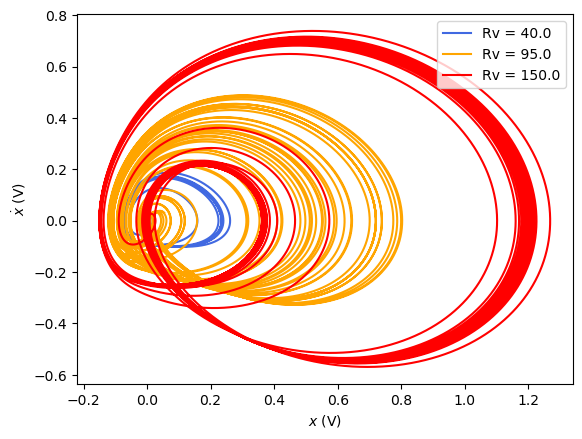

In [103]:
color = ['royalblue','orange','red']
for i in range(n):
    plt.plot(V[i][0],V[i][1],c=color[i],label=f'Rv = {Rv_range[i]}')
plt.legend()
plt.ylabel(r"$\dot{x}$ (V)")
plt.xlabel(r"$x$ (V)")
plt.show()

Animation size has reached 20986256 bytes, exceeding the limit of 20971520.0. If you're sure you want a larger animation embedded, set the animation.embed_limit rc parameter to a larger value (in MB). This and further frames will be dropped.


KeyboardInterrupt: 

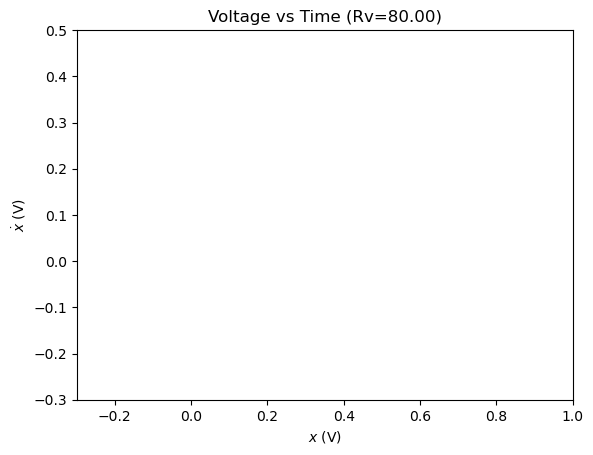

In [99]:
fig, ax = plt.subplots()
t,x,Rv = rk4(Rv=80)

x0 = x[:,0]
x1 = x[:,1]
ax.set_xlim(-0.3, 1)
ax.set_ylim(-0.3, 0.5)

ln, = ax.plot([],[],lw=2,color='royalblue')

ax.set_ylabel(r"$\dot{x}$ (V)")
ax.set_xlabel(r"$x$ (V)")

def init():
    ln.set_data([],[])
    return ln,

window = 10

def update(frame):
    x0 = x[:,0]
    x1 = x[:,1]
    ln.set_data(x0[frame:frame-window], x1[frame:frame-window])
    ax.set_title(f"Voltage vs Time (Rv={Rv:.2f})")
    return ln,

ani = FuncAnimation(fig, update, frames=len(x),init_func=init,blit=True,interval=200)
HTML(ani.to_jshtml())
ani.save("../Model_Figures/phase_space_animation.gif", writer="pillow", fps=5)

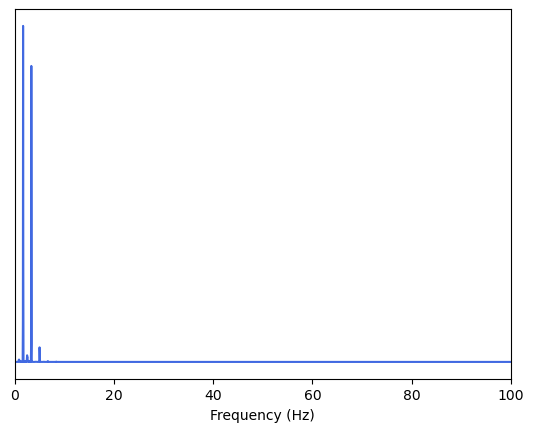

In [ ]:
## FFT code
downsample = 1
t, x = rk4(f,70)
t = t[::downsample]
result = x[:,0]
result = result[::downsample]

result = result - np.mean(result)

dt = t[1] - t[0]
fs = 1/dt

window = np.hamming(len(result))

fft = np.fft.rfft(window*result)

fftfreq = np.fft.rfftfreq(len(result), dt)

plt.plot(fftfreq,np.abs(fft)**2,c='royalblue')
plt.xlim(0,20)
plt.xlabel('Frequency (Hz)')
plt.yticks([])

plt.show()